### **Auto Correlation**

Day Price   Lag1    Lag2
Mon 100     null    null
Tue 105     100     null
wed 108     105     100
Thr 110     108     105

Lag means previous time step
Lag1 Previous value
Lag2 Two previous values
Lag3 Three Previous values

ACF: Correlation between current value and previous lagged values


Partial Auto correlation(PACF):
Day Sales
1   100
2   105
3   110
4   115

Lag relationship
Day4 related to Day3
Day3 related to Day2

PACF finds:
Does Day4 directly depend on Day2?
or only indirect through Day3


Moving Average(2)
---------------
1   1       1
2   1.5     2
3   2.5     2
4   3.5     3
5   4.5     4
5   5       4.33
6   5.5     5.33
7   6.5     6
8   7.5     7


Autocorrelation is a key concept in time series analysis that measures the relationship between a variable and its lagged values. It is widely used in finance, economics, weather forecasting and many other fields to identify trends, seasonality, and temporal dependencies in sequential data.

**Understanding Autocorrelation in Time Series**

Autocorrelation, measures how a time series Xt relates to its past values X t−k where k is the lag. Unlike correlation between two different variables, autocorrelation examines the internal structure of a single series.

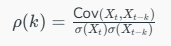

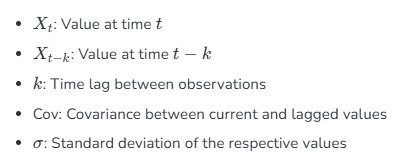

Autocorrelation values near zero suggest little or no linear dependence between current and past observations. Autocorrelation can be computed at different lags to analyze short-term dependencies as well as long-term patterns, making it important for time series analysis and forecasting.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
train_data = pd.read_csv("DailyDelhiClimateTrain.csv")
test_data = pd.read_csv("DailyDelhiClimateTest.csv")

In [4]:
train_data

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000


In [5]:
for df in [train_data, test_data]:
    df["date"] = pd.to_datetime(df["date"])
    df.set_index("date", inplace=True)

In [6]:
train_data["value"] = train_data["meantemp"]
test_data["value"] = test_data["meantemp"]

In [7]:
train_data["lag_1"] = train_data["value"].shift(1)
train_data["lag_7"] = train_data["value"].shift(7)

In [8]:
train_data

,meantemp,humidity,wind_speed,meanpressure,value,lag_1,lag_7
date,,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,10.000000,NaN,NaN
2013-01-02,7.400000,92.000000,2.980000,1017.800000,7.400000,10.000000,NaN
2013-01-03,7.166667,87.000000,4.633333,1018.666667,7.166667,7.400000,NaN
2013-01-04,8.666667,71.333333,1.233333,1017.166667,8.666667,7.166667,NaN
2013-01-05,6.000000,86.833333,3.700000,1016.500000,6.000000,8.666667,NaN
...,...,...,...,...,...,...,...
2016-12-28,17.217391,68.043478,3.547826,1015.565217,17.217391,16.850000,18.050000
2016-12-29,15.238095,87.857143,6.000000,1016.904762,15.238095,17.217391,17.285714
2016-12-30,14.095238,89.666667,6.266667,1017.904762,14.095238,15.238095,15.550000


In [9]:
train_data["rolling_autocorr"] = (
    train_data["value"]
    .rolling(window=30)
    .apply(lambda x: x.autocorr())
)

In [10]:
train_data

,meantemp,humidity,wind_speed,meanpressure,value,lag_1,lag_7,rolling_autocorr
date,,,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,10.000000,NaN,NaN,NaN
2013-01-02,7.400000,92.000000,2.980000,1017.800000,7.400000,10.000000,NaN,NaN
2013-01-03,7.166667,87.000000,4.633333,1018.666667,7.166667,7.400000,NaN,NaN
2013-01-04,8.666667,71.333333,1.233333,1017.166667,8.666667,7.166667,NaN,NaN
2013-01-05,6.000000,86.833333,3.700000,1016.500000,6.000000,8.666667,NaN,NaN
...,...,...,...,...,...,...,...,...
2016-12-28,17.217391,68.043478,3.547826,1015.565217,17.217391,16.850000,18.050000,0.415248
2016-12-29,15.238095,87.857143,6.000000,1016.904762,15.238095,17.217391,17.285714,0.379017
2016-12-30,14.095238,89.666667,6.266667,1017.904762,14.095238,15.238095,15.550000,0.426165


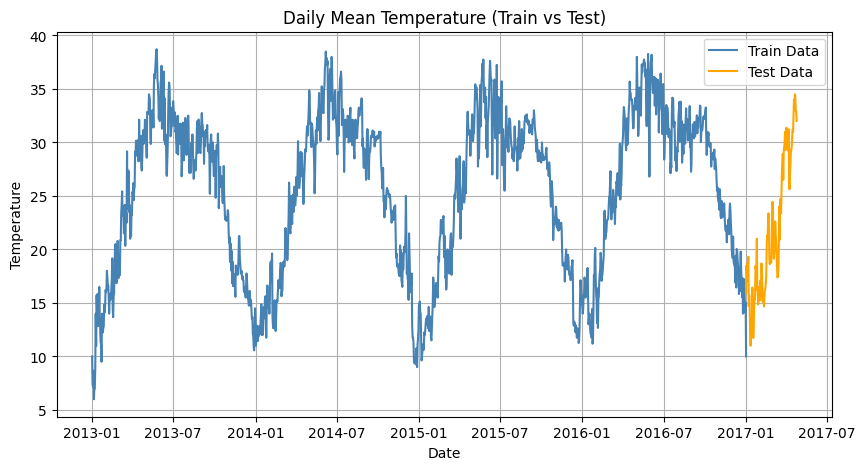

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(train_data.index, train_data["value"], label="Train Data", color="steelblue")
plt.plot(test_data.index, test_data["value"], label="Test Data", color="orange")
plt.title("Daily Mean Temperature (Train vs Test)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

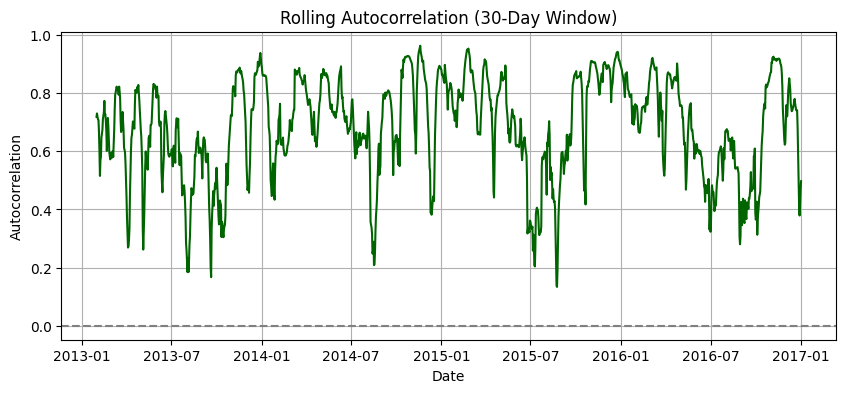

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(train_data.index, train_data["rolling_autocorr"], color="darkgreen")
plt.axhline(0, linestyle="--", color="gray")
plt.title("Rolling Autocorrelation (30-Day Window)")
plt.xlabel("Date")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

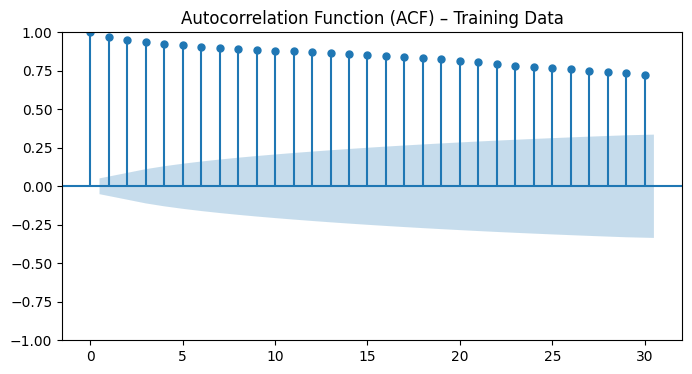

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(train_data["value"].dropna(), lags=30, ax=ax)
ax.set_title("Autocorrelation Function (ACF) – Training Data")
plt.show()

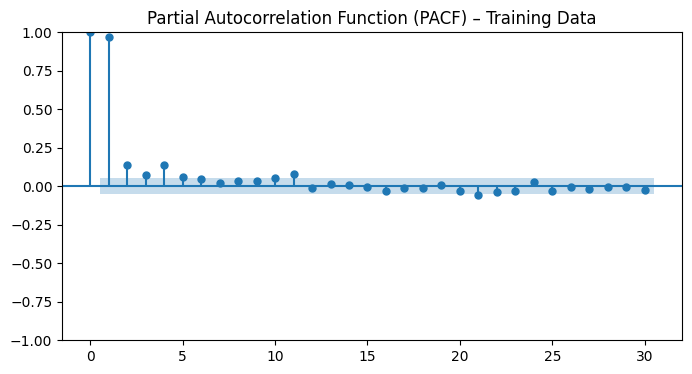

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(train_data["value"].dropna(), lags=30, ax=ax, method="ywm")
ax.set_title("Partial Autocorrelation Function (PACF) – Training Data")
plt.show()